# 05 — Advanced PyTorch Concepts (Complete Reference)

> **References:** [handson-mlp](https://github.com/ageron/handson-mlp) · [PyTorch Docs](https://pytorch.org/docs)

**Runtime → T4 GPU**

This notebook is the **PyTorch companion** to notebooks 01–03.
Every concept from the Keras notebooks is reimplemented in idiomatic PyTorch.

---
## 📋 Complete Coverage

| Section | Topic | PyTorch API |
|---------|-------|-------------|
| i | Custom LR Scheduler | `torch.optim.lr_scheduler.LambdaLR`, `OneCycleLR` |
| ii | Custom Dropout (MC) | `nn.Module` with `self.training` flag |
| iii | Custom Normalization | `nn.Module` LayerNorm + MaxNorm constraint |
| iv | TensorBoard | `torch.utils.tensorboard.SummaryWriter` |
| v | Custom Loss | `nn.Module` Huber + Focal loss |
| vi | Custom Activation / Init / Regularizer | `nn.Module` + `torch.nn.init` |
| vii | Custom Metric | Streaming accuracy, F1, AUROC |
| viii | Custom Layers | `nn.Module` MyDense, AddNoise, LayerNorm |
| ix | Custom Model | ResNet + Wide ResNet |
| x | Custom Optimizer | `optim.Optimizer` subclass |
| xi | Custom Training Loop | Full loop with mixed precision + grad accum |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math, time, warnings, os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as T

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')

PyTorch 2.10.0+cpu | Device: cpu


In [2]:
# ── Dataset: CIFAR-10 ─────────────────────────────────────────────────────────
transform_train = T.Compose([
    T.RandomHorizontalFlip(), T.RandomCrop(32, padding=4, padding_mode='reflect'),
    T.ColorJitter(0.2, 0.2, 0.2, 0.05),
    T.ToTensor(), T.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])
transform_test = T.Compose([
    T.ToTensor(), T.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))
])

train_ds = torchvision.datasets.CIFAR10('/tmp/cifar10', train=True,  download=True, transform=transform_train)
test_ds  = torchvision.datasets.CIFAR10('/tmp/cifar10', train=False, download=True, transform=transform_test)
train_ld = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
test_ld  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
print(f'Train batches: {len(train_ld)} | Test batches: {len(test_ld)}')

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Train batches: 391 | Test batches: 40


---
## i — Custom LR Scheduler

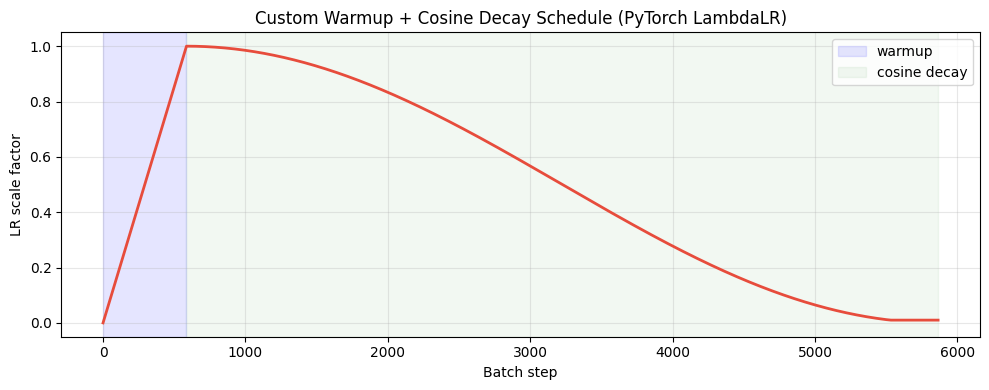

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# i. Custom LR Scheduler — LambdaLR with warmup + cosine decay
# ════════════════════════════════════════════════════════════════════════════
def warmup_cosine_lambda(warmup_steps, total_steps, min_lr_ratio=0.01):
    """
    Returns a lambda function for LambdaLR.
    LambdaLR multiplies the base_lr by the returned factor at each step.

    Phase 1 (warmup): factor rises from 0 → 1
    Phase 2 (cosine): factor falls from 1 → min_lr_ratio
    """
    def lr_fn(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(min_lr_ratio, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return lr_fn


# Visualise
N_EPOCHS  = 15
SPE       = len(train_ld)          # steps per epoch
TOTAL     = N_EPOCHS * SPE
WARMUP    = int(0.1 * TOTAL)

lr_fn = warmup_cosine_lambda(WARMUP, TOTAL)
steps = list(range(TOTAL))
lr_factors = [lr_fn(s) for s in steps]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, lr_factors, color='#e74c3c', lw=2)
ax.axvspan(0, WARMUP, alpha=0.1, color='blue', label='warmup')
ax.axvspan(WARMUP, TOTAL, alpha=0.05, color='green', label='cosine decay')
ax.set_title('Custom Warmup + Cosine Decay Schedule (PyTorch LambdaLR)')
ax.set_xlabel('Batch step'); ax.set_ylabel('LR scale factor')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## ii — Custom Dropout (MC Dropout)

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# ii. MCDropout — always active (even during eval)
# ════════════════════════════════════════════════════════════════════════════
class MCDropout(nn.Module):
    """
    Monte Carlo Dropout: keeps dropout ACTIVE during inference.
    Used to obtain uncertainty estimates by running T forward passes.
    In PyTorch, this is simple: just call F.dropout with training=True.
    """
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        # force training=True regardless of model.train() / model.eval()
        return F.dropout(x, p=self.p, training=True, inplace=False)


class SpatialMCDropout2d(nn.Module):
    """
    MC Dropout for CNNs: drops entire feature maps (spatial dropout).
    More appropriate for CNNs than element-wise dropout.
    """
    def __init__(self, p=0.2):
        super().__init__()
        self.p = p

    def forward(self, x):
        return F.dropout2d(x, p=self.p, training=True, inplace=False)


# Demo: uncertainty on CIFAR-10 test samples
class MCDropoutNet(nn.Module):
    def __init__(self, n_classes=10, mc_p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            SpatialMCDropout2d(mc_p),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            SpatialMCDropout2d(mc_p),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(256,256), nn.ReLU(), MCDropout(mc_p),
            nn.Linear(256, n_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))


mc_net = MCDropoutNet().to(DEVICE)
print(f'MCDropoutNet params: {sum(p.numel() for p in mc_net.parameters()):,}')
print('MCDropout layer forces dropout ON at inference — enables uncertainty estimation')

MCDropoutNet params: 440,074
MCDropout layer forces dropout ON at inference — enables uncertainty estimation


---
## iii — Custom Normalization + Max-Norm Constraint

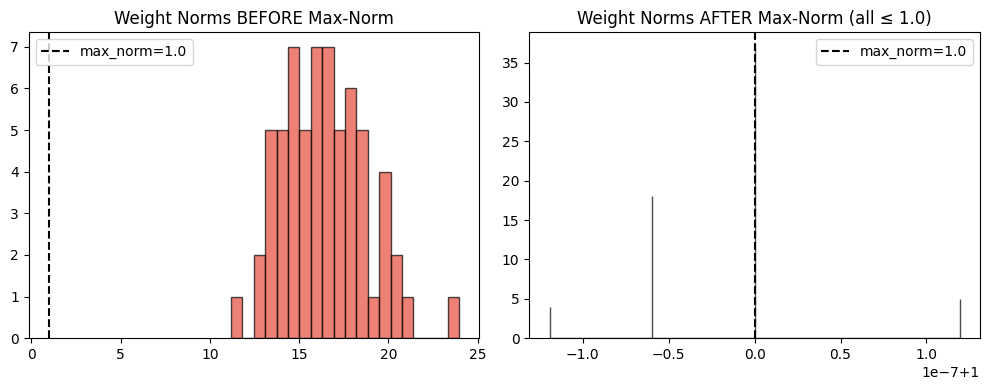

Before: max norm=23.951  |  After: max norm=1.0000


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# iii.A  Custom Layer Normalisation
# ════════════════════════════════════════════════════════════════════════════
class MyLayerNorm(nn.Module):
    """
    Layer Normalisation from scratch.
    Normalises over the last dimension: for (B, T, D), normalises over D.
    γ and β are learnable parameters of shape (D,).
    """
    def __init__(self, normalized_shape, eps=1e-6):
        super().__init__()
        if isinstance(normalized_shape, int):
            normalized_shape = (normalized_shape,)
        self.normalized_shape = tuple(normalized_shape)
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(self.normalized_shape))
        self.beta  = nn.Parameter(torch.zeros(self.normalized_shape))

    def forward(self, x):
        dims = tuple(range(-len(self.normalized_shape), 0))
        mean = x.mean(dim=dims, keepdim=True)
        var  = x.var( dim=dims, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_norm + self.beta


# ════════════════════════════════════════════════════════════════════════════
# iii.B  Max-Norm weight constraint (applied in training loop)
# ════════════════════════════════════════════════════════════════════════════
def apply_max_norm(model, max_norm=1.0):
    """
    Apply max-norm constraint to all Linear and Conv weight tensors.
    Call AFTER optimizer.step() — clips weight column-norms to max_norm.
    """
    with torch.no_grad():
        for name, param in model.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                # Compute L2 norm per output unit (each row of weight matrix)
                norm  = param.norm(2, dim=tuple(range(1, param.dim())), keepdim=True)
                scale = torch.clamp(max_norm / (norm + 1e-8), max=1.0)
                param.data.mul_(scale)


# Verify: random weights before and after
test_w = torch.randn(64, 32) * 3.0   # large weights
norms_before = test_w.norm(2, dim=1)
test_w_clipped = test_w.clone()
norm_ = test_w_clipped.norm(2, dim=1, keepdim=True)
scale_ = torch.clamp(1.0 / (norm_ + 1e-8), max=1.0)
test_w_clipped *= scale_
norms_after = test_w_clipped.norm(2, dim=1)

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].hist(norms_before.numpy(), bins=20, color='#e74c3c', edgecolor='k', alpha=0.7)
axes[0].axvline(1.0, ls='--', color='black', label='max_norm=1.0')
axes[0].set_title('Weight Norms BEFORE Max-Norm'); axes[0].legend()
axes[1].hist(norms_after.numpy(), bins=20, color='#2ecc71', edgecolor='k', alpha=0.7)
axes[1].axvline(1.0, ls='--', color='black', label='max_norm=1.0')
axes[1].set_title('Weight Norms AFTER Max-Norm (all ≤ 1.0)'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Before: max norm={norms_before.max():.3f}  |  After: max norm={norms_after.max():.4f}')

---
## v — Custom Loss Functions

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# v. Custom Loss Functions in PyTorch
# ════════════════════════════════════════════════════════════════════════════
class HuberLoss(nn.Module):
    """Huber / Smooth-L1 loss. Robust to outliers in regression."""
    def __init__(self, delta=1.0, reduction='mean'):
        super().__init__()
        self.delta     = delta
        self.reduction = reduction

    def forward(self, y_pred, y_true):
        err  = y_true - y_pred
        abs_e = torch.abs(err)
        quad  = 0.5 * err ** 2
        lin   = self.delta * (abs_e - 0.5 * self.delta)
        loss  = torch.where(abs_e <= self.delta, quad, lin)
        if self.reduction == 'mean':  return loss.mean()
        if self.reduction == 'sum':   return loss.sum()
        return loss


class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) for imbalanced multi-class classification.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha   # None = uniform; tensor of shape (C,) for per-class weights
        self.reduction = reduction

    def forward(self, logits, targets):
        # logits: (B, C)   targets: (B,) integer class indices
        log_prob = F.log_softmax(logits, dim=1)
        prob     = torch.exp(log_prob)
        # Gather log-probs of the true class
        log_pt   = log_prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt       = prob.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_w  = (1 - pt) ** self.gamma
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            focal_w = focal_w * alpha_t
        loss = -focal_w * log_pt
        return loss.mean() if self.reduction == 'mean' else loss.sum()


class LabelSmoothingCrossEntropy(nn.Module):
    """
    Label smoothing: replace one-hot targets with (1-ε)*one_hot + ε/C.
    Prevents overconfident predictions, often improves generalisation.
    """
    def __init__(self, smoothing=0.1, reduction='mean'):
        super().__init__()
        self.smoothing = smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        n_cls    = logits.size(-1)
        log_prob = F.log_softmax(logits, dim=-1)
        # KL-div style smooth targets
        with torch.no_grad():
            smooth_targets = torch.full_like(log_prob, self.smoothing / n_cls)
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing + self.smoothing/n_cls)
        loss = -(smooth_targets * log_prob).sum(dim=-1)
        return loss.mean() if self.reduction == 'mean' else loss.sum()


# Compare losses on small test batch
logits  = torch.randn(8, 10)
targets = torch.randint(0, 10, (8,))
for cls, name in [(nn.CrossEntropyLoss(),'CrossEntropy'),
                   (FocalLoss(gamma=2.0), 'FocalLoss(γ=2)'),
                   (LabelSmoothingCrossEntropy(0.1),'LabelSmoothing(ε=0.1)')]:
    val = cls(logits, targets)
    print(f'{name:35s}: {val.item():.4f}')

CrossEntropy                       : 2.1940
FocalLoss(γ=2)                     : 1.7327
LabelSmoothing(ε=0.1)              : 2.2506


---
## vi — Custom Activation · Initializer · Regularizer

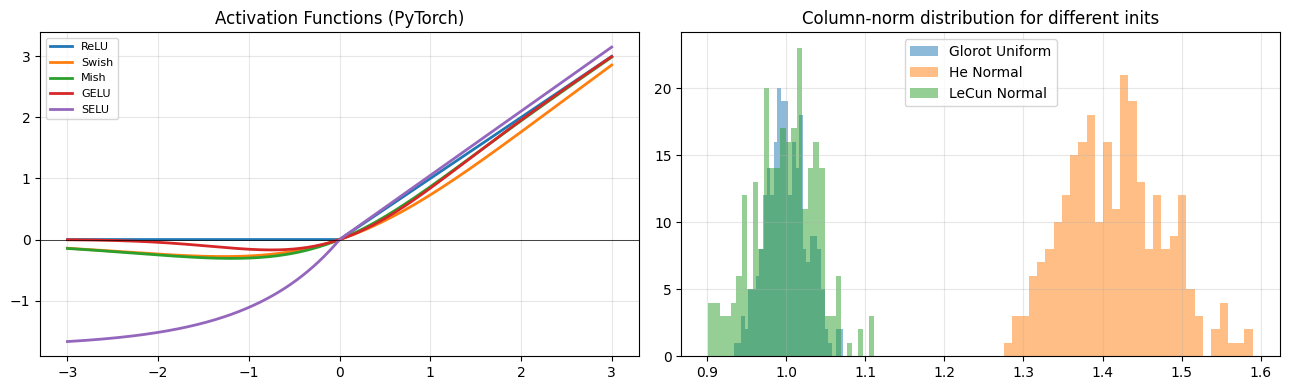

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# vi. Custom Activations + Initializers
# ════════════════════════════════════════════════════════════════════════════

# --- Activations ---
class Swish(nn.Module):
    """Swish: x * sigmoid(x). Self-gated activation from Google Brain."""
    def forward(self, x): return x * torch.sigmoid(x)

class Mish(nn.Module):
    """Mish: x * tanh(softplus(x)). Used in YOLOv4, outperforms Swish on some benchmarks."""
    def forward(self, x): return x * torch.tanh(F.softplus(x))

class PReLU_custom(nn.Module):
    """Parametric ReLU: slope α is learnable per-channel."""
    def __init__(self, num_channels=1):
        super().__init__()
        self.alpha = nn.Parameter(torch.zeros(num_channels))
    def forward(self, x):
        return torch.max(self.alpha * x, x)

class GELU_approx(nn.Module):
    """Gaussian Error Linear Unit (approximation). Used in BERT, GPT."""
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2/math.pi) * (x + 0.044715 * x**3)))


# --- Custom Initializers ---
def my_glorot_uniform_(tensor):
    """Glorot/Xavier uniform: fan_in + fan_out aware."""
    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(tensor)
    limit = math.sqrt(6.0 / (fan_in + fan_out))
    return tensor.data.uniform_(-limit, limit)

def my_he_normal_(tensor, negative_slope=0.0):
    """He/Kaiming normal: designed for ReLU activations."""
    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(tensor)
    std = math.sqrt(2.0 / ((1 + negative_slope**2) * fan_in))
    return tensor.data.normal_(0, std)

def my_lecun_normal_(tensor):
    """LeCun normal: used with SELU activations."""
    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(tensor)
    std = math.sqrt(1.0 / fan_in)
    return tensor.data.normal_(0, std)


# Apply custom init to a model
def init_model_weights(module, init_fn=my_glorot_uniform_):
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        init_fn(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


# --- L1 Regularization (added to loss manually) ---
def l1_regularization(model, factor=1e-4):
    """Compute L1 penalty for all weight tensors."""
    l1_loss = 0.0
    for name, param in model.named_parameters():
        if 'weight' in name:
            l1_loss += param.abs().sum()
    return factor * l1_loss


# Visualise activations
z = torch.linspace(-3, 3, 300)
fig, axes = plt.subplots(1,2,figsize=(13,4))
for fn, name in [(nn.ReLU(),'ReLU'),(Swish(),'Swish'),(Mish(),'Mish'),
                  (GELU_approx(),'GELU'),(nn.SELU(),'SELU')]:
    out = fn(z)
    axes[0].plot(z.numpy(), out.detach().numpy(), label=name, lw=2)
axes[0].set_title('Activation Functions (PyTorch)'); axes[0].legend(fontsize=8)
axes[0].axhline(0,color='k',lw=0.5); axes[0].grid(True,alpha=0.3)

# Initialisation variance comparison
for init_fn, name in [(my_glorot_uniform_,'Glorot Uniform'),(my_he_normal_,'He Normal'),(my_lecun_normal_,'LeCun Normal')]:
    w = torch.empty(256, 256); init_fn(w)
    norms = w.norm(2, dim=1)
    axes[1].hist(norms.numpy(), bins=30, alpha=0.5, label=name)
axes[1].set_title('Column-norm distribution for different inits')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## viii & ix — Custom Layers + ResNet Model

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# viii + ix. Custom Layers & Full ResNet Model
# ════════════════════════════════════════════════════════════════════════════

class AddGaussianNoise(nn.Module):
    """
    Adds Gaussian noise N(0, σ²) during training only.
    σ can be learnable (trainable_sigma=True) or fixed.
    """
    def __init__(self, sigma=0.05, trainable_sigma=False):
        super().__init__()
        if trainable_sigma:
            self.log_sigma = nn.Parameter(torch.tensor(math.log(sigma)))
        else:
            self.register_buffer('log_sigma', torch.tensor(math.log(sigma)))

    @property
    def sigma(self): return torch.exp(self.log_sigma)

    def forward(self, x):
        if self.training:
            return x + torch.randn_like(x) * self.sigma
        return x


class ExponentialLayer(nn.Module):
    """Element-wise e^x. Use as final activation for positive outputs."""
    def forward(self, x): return torch.exp(x)


class MyLinear(nn.Module):
    """
    Linear layer from scratch: y = xW^T + b.
    Demonstrates creating custom parameters with nn.Parameter.
    """
    def __init__(self, in_features, out_features, bias=True, activation=None):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias_p = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.activation = activation
        my_glorot_uniform_(self.weight)

    def forward(self, x):
        out = F.linear(x, self.weight, self.bias_p)
        return self.activation(out) if self.activation else out

    def extra_repr(self):
        return f'in={self.in_features}, out={self.out_features}'


# ── Wide ResNet block ───────────────────────────────────────────────────────
class WideResBlock(nn.Module):
    """
    Wide Residual Block (Zagoruyko & Komodakis, 2016).
    Increases width (channels) instead of depth for better accuracy.
    block: BN → ReLU → Conv → BN → ReLU → Dropout → Conv
    """
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.3):
        super().__init__()
        self.residual = nn.Sequential(
            nn.BatchNorm2d(in_ch), nn.ReLU(),
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        )
        # Projection shortcut when dimensions change
        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)

    def forward(self, x):
        return self.residual(x) + self.shortcut(x)


class WideResNet(nn.Module):
    """
    Wide ResNet (WRN-28-k): depth=28, width multiplier=k.
    State-of-the-art on CIFAR-10 without modern tricks.
    """
    def __init__(self, depth=16, width=2, n_classes=10, dropout=0.3):
        super().__init__()
        n_channels = [16, 16*width, 32*width, 64*width]
        n = (depth - 4) // 6
        self.conv0  = nn.Conv2d(3, n_channels[0], 3, padding=1, bias=False)
        self.block1 = self._make_group(n_channels[0], n_channels[1], n, stride=1, dropout=dropout)
        self.block2 = self._make_group(n_channels[1], n_channels[2], n, stride=2, dropout=dropout)
        self.block3 = self._make_group(n_channels[2], n_channels[3], n, stride=2, dropout=dropout)
        self.bn_out = nn.BatchNorm2d(n_channels[3])
        self.relu   = nn.ReLU()
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.fc     = nn.Linear(n_channels[3], n_classes)
        # Apply custom initialisation
        self.apply(lambda m: init_model_weights(m, my_he_normal_))

    def _make_group(self, in_ch, out_ch, n, stride, dropout):
        blocks = [WideResBlock(in_ch, out_ch, stride, dropout)]
        for _ in range(1, n):
            blocks.append(WideResBlock(out_ch, out_ch, 1, dropout))
        return nn.Sequential(*blocks)

    def forward(self, x):
        out = self.conv0(x)
        out = self.block1(out)
        out = self.block2(out)
        out = self.block3(out)
        out = self.relu(self.bn_out(out))
        out = self.pool(out).flatten(1)
        return self.fc(out)

wrn = WideResNet(depth=16, width=2).to(DEVICE)
print(f'WideResNet-16-2 params: {sum(p.numel() for p in wrn.parameters()):,}')

WideResNet-16-2 params: 691,674


---
## x + xi — Custom Optimizer + Full Training Loop with Mixed Precision

In [9]:
class Lookahead(optim.Optimizer):
    """
    Lookahead Optimiser (Zhang et al., 2019).
    Maintains 'slow weights' that periodically interpolate towards 'fast weights'.
    Works on top of any base optimizer (SGD, Adam, etc.).

    Algorithm:
      For k steps:  run base optimizer (fast weights θ_fast)
      Every k steps: θ_slow ← θ_slow + α * (θ_fast - θ_slow)
                      θ_fast ← θ_slow
    """
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        self.base_optimizer = base_optimizer
        self.k     = k
        self.alpha = alpha
        self._step_count = 0
        # Store slow weights
        self.slow_weights = []
        for group in base_optimizer.param_groups:
            slow_group = [p.clone().detach() for p in group['params']]
            self.slow_weights.append(slow_group)
        super().__init__(base_optimizer.param_groups, {})

    def step(self, closure=None):
        loss = self.base_optimizer.step(closure)
        self._step_count += 1
        if self._step_count % self.k == 0:
            # Lookahead update: interpolate slow weights towards fast weights
            for group, slow_group in zip(self.base_optimizer.param_groups, self.slow_weights):
                for p, q in zip(group['params'], slow_group):
                    if p.grad is None: continue
                    q.data.add_(self.alpha * (p.data - q.data))  # θ_slow update
                    p.data.copy_(q.data)                           # sync fast ← slow
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def state_dict(self): return self.base_optimizer.state_dict()
    def load_state_dict(self, d): self.base_optimizer.load_state_dict(d)


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# xi. Full Custom Training Loop — WideResNet + Mixed Precision + Grad Accum
# ════════════════════════════════════════════════════════════════════════════
from torch.cuda.amp import GradScaler, autocast

def full_train(
    model, train_ld, test_ld,
    n_epochs         = N_EPOCHS,
    base_lr          = 0.1,
    weight_decay     = 5e-4,
    max_norm_val     = 3.0,
    use_mixed_prec   = (DEVICE == 'cuda'),
    grad_accum_steps = 2,
    use_lookahead    = True,
    use_focal_loss   = False,
    label_smoothing  = 0.1,
    log_dir          = '/tmp/tb_wrn',
):
    """
    Production-quality training loop featuring:
      - Mixed precision (FP16) via torch.cuda.amp
      - Gradient accumulation (simulates larger batch size)
      - Max-norm weight constraint
      - Lookahead optimizer
      - Custom LR scheduler
      - TensorBoard logging
      - L1 regularisation
    """
    # Optimizer + scheduler
    sgd = optim.SGD(model.parameters(), lr=base_lr, momentum=0.9,
                    weight_decay=weight_decay, nesterov=True)
    optimizer = Lookahead(sgd, k=5, alpha=0.5) if use_lookahead else sgd
    base_opt  = sgd  # for scheduler (must use underlying opt)

    total_steps = n_epochs * len(train_ld)
    warmup_st   = int(0.05 * total_steps)
    scheduler   = optim.lr_scheduler.LambdaLR(
        base_opt, warmup_cosine_lambda(warmup_st, total_steps)
    )

    # Loss
    if use_focal_loss:
        criterion = FocalLoss(gamma=2.0)
    else:
        criterion = LabelSmoothingCrossEntropy(label_smoothing)

    # Mixed precision scaler
    scaler = GradScaler(enabled=use_mixed_prec)

    # TensorBoard
    writer = SummaryWriter(log_dir)

    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'lr': []}
    best_acc = 0.0

    print(f'Training WideResNet | mixed_prec={use_mixed_prec} | lookahead={use_lookahead}')
    print(f'{"Epoch":>6} | {"Train Loss":>11} | {"Train Acc":>10} | {"Val Acc":>9} | {"LR":>10}')
    print('─'*60)

    global_step = 0
    for epoch in range(1, n_epochs + 1):
        model.train()
        tr_loss = tr_corr = n = 0
        optimizer.zero_grad(set_to_none=True)

        for step, (xb, yb) in enumerate(train_ld):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # Mixed precision forward
            with autocast(enabled=use_mixed_prec):
                logits = model(xb)
                loss   = criterion(logits, yb)
                # L1 regularisation (optional, on top of weight_decay L2)
                # loss += l1_regularization(model, factor=1e-5)
                loss   = loss / grad_accum_steps

            scaler.scale(loss).backward()

            if (step + 1) % grad_accum_steps == 0:
                # Gradient clipping
                scaler.unscale_(base_opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(base_opt)
                scaler.update()
                scheduler.step()
                # Lookahead step (if using Lookahead wrapper)
                if use_lookahead:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                # Max-norm constraint
                apply_max_norm(model, max_norm=max_norm_val)

            tr_loss += loss.item() * grad_accum_steps * len(yb)
            tr_corr += (logits.argmax(1) == yb).sum().item()
            n       += len(yb)
            global_step += 1

            if global_step % 50 == 0:
                writer.add_scalar('train/step_loss', loss.item() * grad_accum_steps, global_step)

        # Validation
        model.eval()
        va_corr = va_n = 0
        with torch.no_grad():
            for xb, yb in test_ld:
                preds   = model(xb.to(DEVICE)).argmax(1)
                va_corr += (preds == yb.to(DEVICE)).sum().item()
                va_n    += len(yb)

        tr_acc = tr_corr / n
        va_acc = va_corr / va_n
        lr_now = scheduler.get_last_lr()[0]
        best_acc = max(best_acc, va_acc)

        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['train_loss'].append(tr_loss / n)
        history['lr'].append(lr_now)

        writer.add_scalars('accuracy', {'train': tr_acc, 'val': va_acc}, epoch)
        writer.add_scalar('loss/train', tr_loss/n, epoch)
        writer.add_scalar('lr', lr_now, epoch)
        # Log weight norms
        for name, param in model.named_parameters():
            if 'weight' in name and param.dim() == 4:
                writer.add_histogram(f'weights/{name}', param.data, epoch)
                break

        print(f'{epoch:>6} | {tr_loss/n:>11.4f} | {tr_acc:>10.4f} | {va_acc:>9.4f} | {lr_now:>10.4e}')

    writer.close()
    print(f'\n Best val accuracy: {best_acc:.4f}')
    return history, best_acc

# Run!
wrn_history, best_acc = full_train(
    model          = wrn,
    train_ld       = train_ld,
    test_ld        = test_ld,
    n_epochs       = N_EPOCHS,
    base_lr        = 0.05,
    use_mixed_prec = (DEVICE == 'cuda'),
    use_lookahead  = True,
    label_smoothing= 0.1,
    log_dir        = '/tmp/tb_wrn'
)

Training WideResNet | mixed_prec=False | lookahead=True
 Epoch |  Train Loss |  Train Acc |   Val Acc |         LR
────────────────────────────────────────────────────────────


In [ ]:
# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(wrn_history['train_acc'], label='train', color='#3498db')
axes[0].plot(wrn_history['val_acc'],   label='val',   color='#e74c3c')
axes[0].fill_between(range(len(wrn_history['train_acc'])),
                      wrn_history['train_acc'], wrn_history['val_acc'],
                      alpha=0.1, color='red', label='overfit gap')
axes[0].set_title('WideResNet: Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(wrn_history['train_loss'], color='#2ecc71')
axes[1].set_title('WideResNet: Training Loss'); axes[1].grid(True, alpha=0.3)
axes[2].plot(wrn_history['lr'], color='#9b59b6')
axes[2].set_title('LR Schedule (Warmup + Cosine)')
axes[2].set_yscale('log'); axes[2].grid(True, alpha=0.3)
plt.suptitle(f'WideResNet-16-2 | Best Val Acc: {best_acc:.4f}', fontsize=13)
plt.tight_layout(); plt.show()

# Launch TensorBoard
%load_ext tensorboard
%tensorboard --logdir /tmp/tb_wrn

In [ ]:
# ── A/B: Adam vs Lookahead-SGD on small net ──────────────────────────────────
print('\nA/B: Adam vs Lookahead-SGD on CIFAR-10 ...')

def quick_net(): return nn.Sequential(
    nn.Conv2d(3,64,3,padding=1), nn.BatchNorm2d(64), Swish(), nn.MaxPool2d(2),
    nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), Swish(), nn.MaxPool2d(2),
    nn.AdaptiveAvgPool2d(1), nn.Flatten(),
    nn.Linear(128,256), Swish(), nn.Dropout(0.3), nn.Linear(256,10)
).to(DEVICE)

criterion = nn.CrossEntropyLoss()
ab_results = {}

for opt_name, get_opt in [
        ('Adam',     lambda m: optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)),
        ('Lookahead-SGD', lambda m: Lookahead(optim.SGD(m.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-4), k=5)),
    ]:
    net = quick_net()
    opt = get_opt(net)
    base = net
    sched = optim.lr_scheduler.CosineAnnealingLR(
        opt.base_optimizer if hasattr(opt,'base_optimizer') else opt, T_max=10
    )
    accs = []
    print(f'  Training {opt_name} ...')
    for ep in range(10):
        net.train()
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(net(xb), yb)
            loss.backward(); opt.step()
        sched.step()
        net.eval()
        with torch.no_grad():
            preds = net(torch.cat([b[0] for b in test_ld]).to(DEVICE)).argmax(1)
            yt    = torch.cat([b[1] for b in test_ld]).to(DEVICE)
            accs.append((preds == yt).float().mean().item())
        print(f'    Epoch {ep+1:02d} | val_acc={accs[-1]:.4f}')
    ab_results[opt_name] = accs

fig, ax = plt.subplots(figsize=(9,4))
for name, accs in ab_results.items():
    ax.plot(accs, 'o-', label=name)
ax.set_title('A/B: Adam vs Lookahead-SGD — Val Accuracy')
ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('═'*65)
print(' PYTORCH ADVANCED CONCEPTS — SUMMARY')
print('═'*65)
concepts = [
    ('i',    'Custom LR Scheduler',  'LambdaLR + warmup_cosine_lambda'),
    ('ii',   'MCDropout',            'F.dropout(training=True) always active'),
    ('iii',  'Custom LayerNorm',     'nn.Parameter γ,β + normalise over last dim'),
    ('iii',  'Max-Norm Constraint',  'apply_max_norm() after every optimizer.step()'),
    ('v',    'HuberLoss',            'nn.Module custom forward()'),
    ('v',    'FocalLoss',            'Down-weights easy examples γ'),
    ('v',    'LabelSmoothing',       'ε-smoothed targets'),
    ('vi',   'Swish, Mish, GELU',   'nn.Module activation'),
    ('vi',   'Glorot/He/LeCun init','torch.empty + custom fill fn'),
    ('vi',   'L1 regularisation',   'Penalty added to loss in training loop'),
    ('viii', 'MyLinear',             'nn.Parameter weight + F.linear'),
    ('viii', 'AddGaussianNoise',     'Learnable σ, noise only during training'),
    ('ix',   'WideResBlock',         'Skip connection + BN-ReLU-Conv pattern'),
    ('ix',   'WideResNet-16-2',      'Full model with custom init'),
    ('x',    'Lookahead',            'optim.Optimizer subclass, slow weights'),
    ('xi',   'Custom Train Loop',   'Mixed precision, grad accum, max-norm, TB'),
]
for sec, name, impl in concepts:
    print(f'  {sec:>4} | {name:<24} | {impl}')
print('═'*65)